# Lilium Tower

## Parametrization and Channel Generation

In [1]:
import sys; sys.path.append('.')
import inflation, sparse_matrices, mesh, numpy as np, importlib, pickle, wall_generation
import inflatables_parametrization as parametrization
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization, wall_width_formulas as wwf

In [2]:
sys.path.append('periodic_patches/')

In [3]:
from py_newton_optimizer import NewtonOptimizerOptions

In [4]:
import MeshFEM, parallelism, benchmark, utils
parallelism.set_max_num_tbb_threads(8)
parallelism.set_gradient_assembly_num_threads(8)
parallelism.set_hessian_assembly_num_threads(8)

In [8]:
# lilium = mesh.Mesh("../examples/igloo.obj")
# lilium = mesh.Mesh("../examples/lilium.msh")
lilium = mesh.Mesh("../examples/cone.obj")

lg = parametrization.LocalGlobalGenericParametrizer(lilium, parametrization.lscm(lilium))

print(lg.energy())

lg.alphaMin = 1.0
lg.alphaMax = 1.5 #np.pi / 2

lg.betaMin = 1.0
lg.betaMax = 1.5 #np.pi / 2

# lg.alphaMin = 1.354641650129586
# lg.alphaMax = 1.3936682623611498

# lg.betaMin = 1.1282764273066557
# lg.betaMax = 1.141976581731514

print(lg.energy())
lg.runIteration()
print(lg.energy())

# rparam = parametrization.RegularizedGenericParametrizer(lg)
for i in range(1000): lg.runIteration()
# print(lg.energy())

0.3459310015290067
0.316292726796606
0.08120615131524052


In [9]:
lg.numFlips()

0

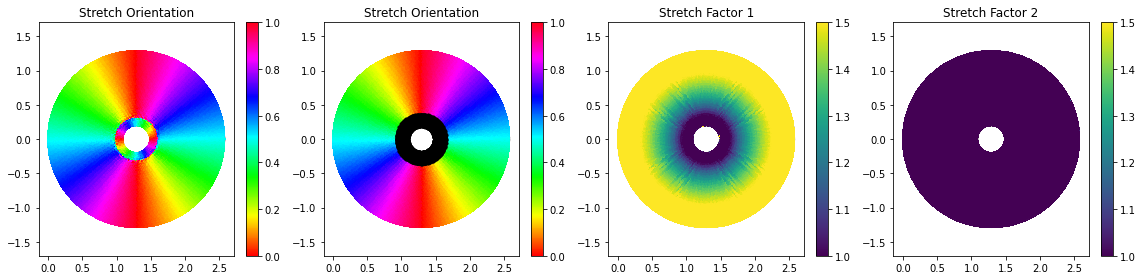

In [10]:
visualization.visualize_both(lg, height = 4)